# Diabetes Prediction Using Machine Learning Classification Models

## Objective
To create a classification model that can predict if someone will develop diabetes over the next 5 years.

## About the dataset
The dataset consists of information on Pregnancies, Glucose, Blood Pressure, 
Skin Thickness, Insulin BMI, Diabetes Pedigree Functio,n and Age – along with the outcome of whether
or not they had diabete
## Methodology:
1. Import necessary libraries.
2. Data exploration and visualization.
3. Data preprocessing and cleaning.
4. Train/Test split.
5. Modeling & Evaluation.
6. Results.s.

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
import scipy.optimize as opt
import seaborn as sns
from sklearn import preprocessing
%matplotlib inline

## Importing Dataset

In [2]:
# Read the diabetes dataset from the CSV file and display the first few rows
diabetes_ds = pd.read_csv("Diabetes-2-1.csv")
diabetes_ds.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Exploration and Visualization

In [3]:
# Display concise summary information about the diabetes dataset
diabetes_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Check for missing values in the diabetes dataset and display the count of null values for each column
diabetes_ds.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

All columns have a **minimum value of 0** which is clearly not logical,these are essentially **missing values** in our dataset except in the columns where they are valid for example in the "Pregnancies" and "Outcome" columns. 

Outcome
0    500
1    268
Name: count, dtype: int64


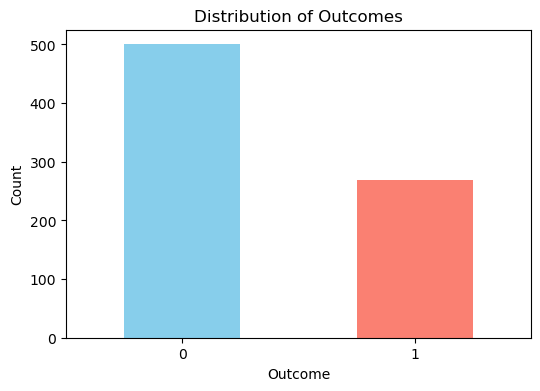

In [5]:
# Checking the occurrences of each outcome in the "Outcome" column
outcome_counts = diabetes_ds["Outcome"].value_counts()

# Print outcome counts
print(outcome_counts)

# Plot bar chart to visualize the distribution of outcomes
plt.figure(figsize=(6, 4))
outcome_counts.plot(kind="bar", color=['skyblue', 'salmon'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Outcomes')
plt.xticks(rotation=0)  # Rotate x-labels if needed
plt.show()

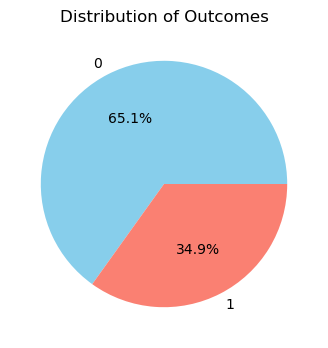

In [6]:
# Plotting a pie chart to visualize the distribution of outcomes
plt.figure(figsize=(4, 4))
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Distribution of Outcomes')
plt.show()

In [7]:
#Let's have a descriptive exploration of our data
diabetes_ds.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


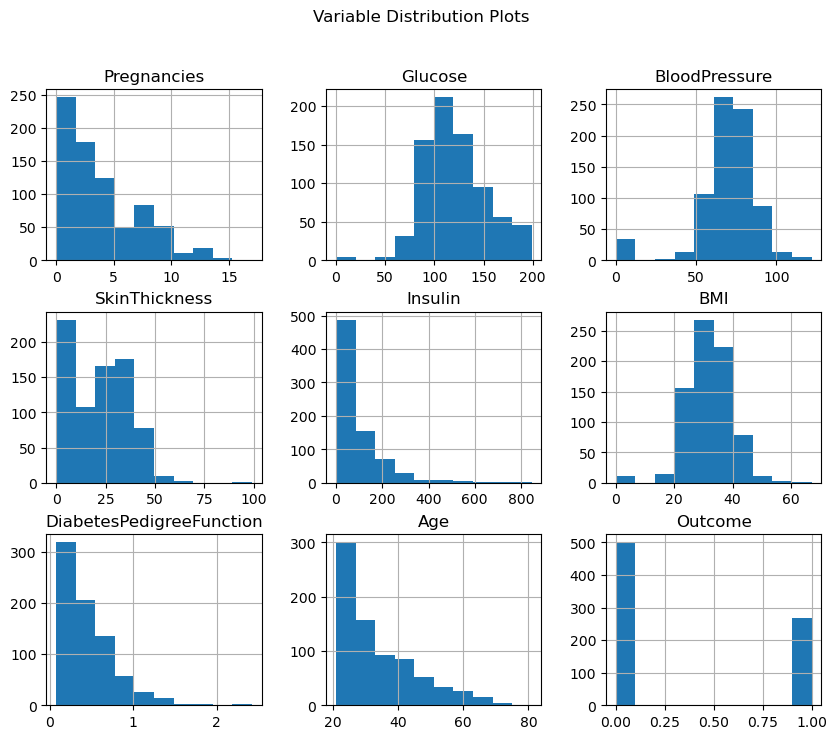

In [8]:
#Lets further explore our dataset by visualizing its variables
viz = diabetes_ds
viz.hist(figsize=(10, 8), bins=10)
plt.suptitle("Variable Distribution Plots")
plt.show()

In [9]:
# Check how the variables correlate 
diabetes_ds.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [10]:
# Identify Columns with missing values excluding the first and last columns where the zeroes are valid
missing_value_columns = diabetes_ds.columns[1:-1][diabetes_ds.iloc[:, 1:-1].isin([0]).any()].tolist()

# Create a data frame displaying features with missing values & their frequencies
missing_value_df = diabetes_ds[missing_value_columns].isin([0]).sum()

print("Columns with missing values:\n", missing_value_columns)
print("Frequency of missing values:\n", missing_value_df)

Columns with missing values:
 ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
Frequency of missing values:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


# Data Pre-processing and Cleaning

In [11]:
# Make a copy of the original dataset
diabetes_ds_copy = diabetes_ds.copy(deep = True)
# List the columns where missing values should be replaced
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace missing values with NaN only in specified columns
diabetes_ds_copy[columns_to_replace] = diabetes_ds_copy[columns_to_replace].replace(0, np.nan)
diabetes_ds_copy

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


By selectively replacing missing values with NaN only in the specified columns,we handle missing values without affecting the rest of the dataset this preserves the logical meaning of 0 values in columns where they are valid for instance in the 'Pregnancies' and 'Outcome' columns.

In [12]:
# Calculate the mean of each column in the diabetes_ds_copy
diabetes_ds_copy.mean()

Pregnancies                   3.845052
Glucose                     121.686763
BloodPressure                72.405184
SkinThickness                29.153420
Insulin                     155.548223
BMI                          32.457464
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

In [13]:
# Fill in missing values (NaN) in the dataset with the mean value of each column
diabetes_ds_copy.fillna(diabetes_ds_copy.mean(), inplace=True)
diabetes_ds_copy

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1


In [14]:
# Checking for missing values once more
zero_counts = (diabetes_ds_copy[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print(zero_counts)

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Define the features (X ) and the target variable (y)

In [15]:
# Extracting features (X) and target variable (y) from the diabetes dataset copy
X = diabetes_ds_copy.iloc[:, :-1].values #Features (independent variables)
y = diabetes_ds_copy.iloc[:, -1].values #Target variable (dependent variable)

In [16]:
print(X)

[[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]


In [17]:
print(y)

[1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 0 0 1
 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 1 0 1
 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 

# Train/Test Split

In [18]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state =0)

X_train represents features for training,X_test; features for testing,y_train; Target variable for training & y_test; Target variable for testing.The dataset is split with 20% reserved for testing and a random state set for reproducibility.

In [19]:
# print the shape of the split sets
print("Train Set:",X_train.shape,y_train.shape)
print("Test Set:",X_test.shape,y_test.shape)

Train Set: (614, 8) (614,)
Test Set: (154, 8) (154,)


# Feature Scaling

In [20]:
# Standardizing the features using StandardScaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [21]:
X_test

array([[-0.89295432,  2.48505495,  0.36797839, ...,  1.75741893,
         2.78935129, -0.93064283],
       [-0.56553774, -0.47180508,  0.20642998, ...,  0.28879083,
        -0.27698825, -0.83598035],
       [ 0.08929543, -1.46813834, -0.76286054, ...,  0.35195763,
        -0.31725331, -0.64665539],
       ...,
       [ 0.08929543,  0.65308732,  1.17572049, ...,  1.93112763,
         0.4694641 , -0.93064283],
       [-0.23812115, -0.18254703,  0.20642998, ..., -0.86400328,
        -1.19689011, -0.74131787],
       [-0.89295432, -0.47180508,  0.04488156, ..., -0.15337678,
         1.01459113, -0.74131787]])

In [22]:
X_train

array([[ 0.90832902,  0.93627156,  0.44607305, ...,  0.36780137,
         0.67740401,  1.69955804],
       [ 0.03644676, -0.81645845, -1.05366073, ..., -0.63382702,
        -0.07049698, -0.96569189],
       [-1.12606292,  1.43232723,  1.44589558, ...,  2.81463643,
        -0.11855487, -0.88240283],
       ...,
       [ 0.03644676, -0.91566959, -0.63706802, ..., -1.13464121,
        -0.95656442, -1.04898095],
       [ 2.0708387 , -1.21330299,  0.11279888, ..., -0.36195646,
        -0.50001442,  0.11706589],
       [ 0.32707418,  0.47328628,  0.77934723, ..., -0.02462752,
         0.52121586,  2.94889395]])

# Model Building

#### 1.Decision Tree

In [23]:
#Import the necessary classifiers
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree

In [24]:
#create an instance of the DecisionTreeClassifier called DT_classifier
#Inside the classifier we specify criterion="entropy" so we can see information gain of each node
DT_classifier = DecisionTreeClassifier(criterion="entropy",max_depth =3, random_state=0)
DT_classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

Prediction

In [25]:
# Make predictions on test dataset
ypred_DT= DT_classifier.predict(X_test)
ypred_DT

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
      dtype=int64)

In [26]:
ytrainpred_DT=DT_classifier.predict(X_train)
ytrainpred_DT

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,

Evaluation

In [27]:
# Check the accuracy of the model
from sklearn import metrics
from sklearn.metrics import accuracy_score

# Calculate accuracy score
DT_accuracy =accuracy_score(y_test, ypred_DT)
print("DecisionTree's Accuracy is", DT_accuracy)

DecisionTree's Accuracy is 0.7662337662337663


[[93 14]
 [22 25]]


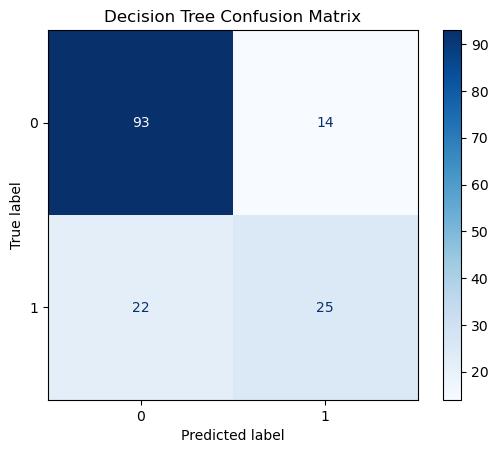

In [28]:
# Employ confusion matrix to evaluate sensitivity and specificity based on the predictions made
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
cm_DT = confusion_matrix(y_test, ypred_DT)
print(cm_DT)
# Plot confusion matrix
disp_DT = ConfusionMatrixDisplay(confusion_matrix=cm_DT,display_labels=DT_classifier.classes_)
disp_DT.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.savefig('Decision_Tree_Confusion_Matrix.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

In the first row, representing individuals with an actual outcome value of 0, out of 154 cases, 107 were correctly identified as 0 by the classifier. However, 14 were mistakenly classified as 1. Despite these misclassifications, the majority were correctly predicted, showcasing the model's effectiveness.

Conversely, in the second rowpertaining toto individuals with an actual outcome value of 1, the classifier correctly identified 25 out of 47 cases. However, it misclassified 22 cases as 0. While this aspect indicates room for improvement, the overall performance remains reasonable.tives.

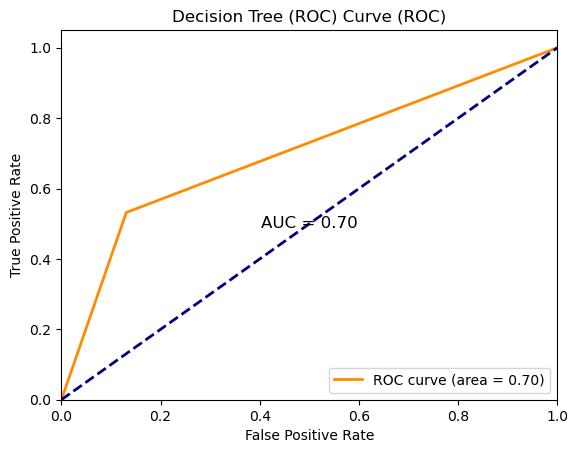

In [29]:
from sklearn.metrics import roc_curve, auc
# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, ypred_DT)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree (ROC) Curve (ROC)')
plt.legend(loc="lower right")
plt.text(0.5, 0.5, 'AUC = %0.2f' % roc_auc, ha='center', va='center', fontsize=12)
plt.savefig('DT (ROC)Curve.png')
plt.show()

In [30]:
# Print the classification report to evaluate the performance of the DT_classifier
print(classification_report(y_test, ypred_DT))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       107
           1       0.64      0.53      0.58        47

    accuracy                           0.77       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.76      0.77      0.76       154



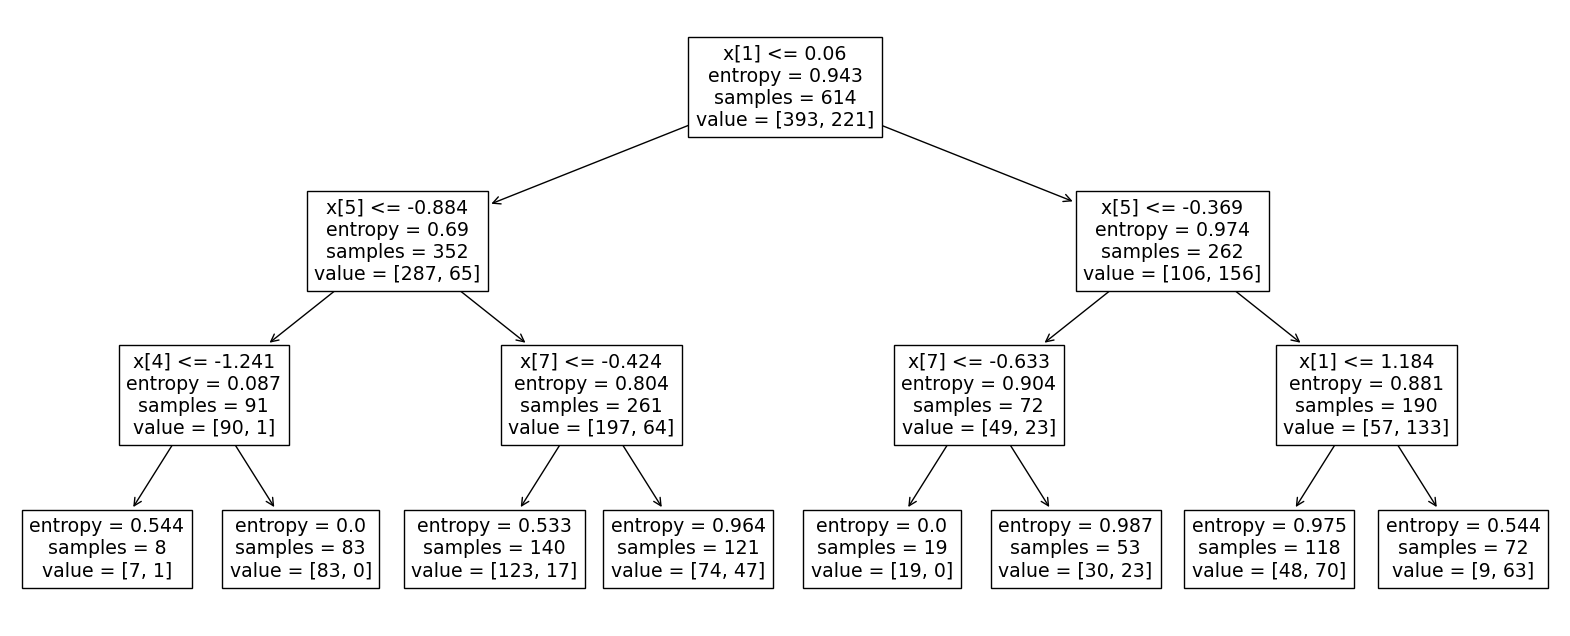

In [31]:
# Visualize the tree
plt.figure(figsize=(20,8))
tree.plot_tree(DT_classifier)
plt.show()

### 2.Logistics Regression

In [32]:
# Import & create an instance of the LogisticRegressionClassifier with specified parameters
# Fit the Classifier on the training data
from sklearn.linear_model import LogisticRegression
LR_classifier = LogisticRegression(C=1.0, solver='liblinear',random_state = 0)
LR_classifier.fit(X_train,y_train)

LogisticRegression(random_state=0, solver='liblinear')

In [33]:
# Make prediction using the testset
ypred_LR = LR_classifier.predict(X_test)
ypred_LR

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
      dtype=int64)

Evaluation

In [34]:
# Calculating the accuracy score of the Logistic Regression predictions on the test set
from sklearn import metrics
# Calculate LR accuracy score
LR_accuracy =accuracy_score(y_test, ypred_LR)
print("Logistic Regression Accuracy is", LR_accuracy)

Logistic Regression Accuracy is 0.8116883116883117


[[96 11]
 [18 29]]


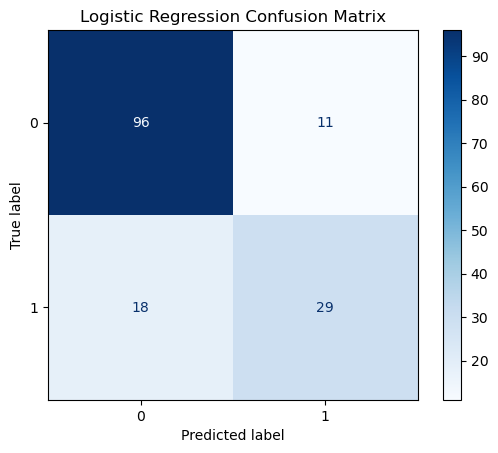

In [35]:
# Employ confusion matrix to assess sensitivity and specificity based on the predictions made
# Calculate confusion matrix
cm_LR = confusion_matrix(y_test, ypred_LR)
print(cm_LR)
# Plot confusion matrix
disp_LR = ConfusionMatrixDisplay(confusion_matrix=cm_LR,display_labels=LR_classifier.classes_)
disp_LR.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.savefig('Logistic Regression Confusion Matrix.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

Out of a total of 107 individuals with an actual outcome of 0, the classifier correctly predicted 96 as 0 and misclassified 11 as 1.

Similarly, out of a total of 47 individuals with an actual outcome of 1, the classifier correctly predicted 29 as 1 but misclassified 18 as 0.The classifier demonstrates relatively strong performance in correctly predicting outcomes for both classes, with a higher accuracy in predicting outcomes for class 0. ses.

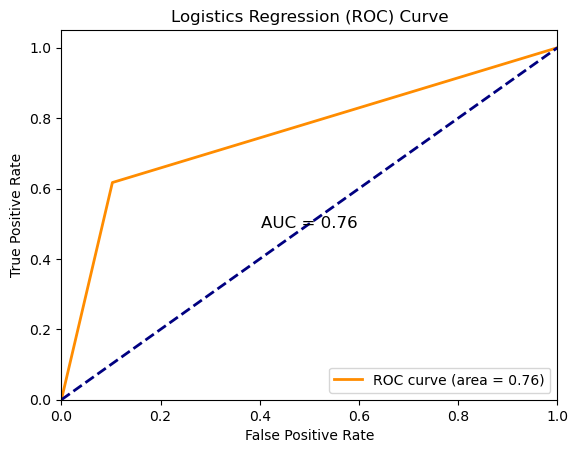

In [36]:
# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, ypred_LR)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistics Regression (ROC) Curve')
plt.legend(loc="lower right")
plt.text(0.5, 0.5, 'AUC = %0.2f' % roc_auc, ha='center', va='center', fontsize=12)
plt.savefig('LR (ROC) Curve.png')
plt.show()

In [37]:
# Print the classification report to evaluate the performance of the LR_classifier
print(classification_report(y_test, ypred_LR))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       107
           1       0.72      0.62      0.67        47

    accuracy                           0.81       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.81      0.81      0.81       154



### 3.Support Vector Machine (SVM)

In [38]:
# Import & create an instance of the SupportVectorClassifier(SVC) with specified parameters
# Fit the Classifier on the training data
from sklearn.svm import SVC
SVM_classifier = SVC(kernel = 'linear',C=0.1,gamma='scale',class_weight='balanced',random_state=0,probability=True)
SVM_classifier.fit(X_train,y_train)

SVC(C=0.1, class_weight='balanced', kernel='linear', probability=True,
    random_state=0)

In [39]:
# Make prediction using the testset
ypred_SVM = SVM_classifier.predict(X_test)
ypred_SVM

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
      dtype=int64)

In [40]:
#Checking SVM'S accuracy
SVM_accuracy =accuracy_score(y_test, ypred_SVM)
print("Support Vector Machine Accuracy is", SVM_accuracy)

Support Vector Machine Accuracy is 0.7792207792207793


[[83 24]
 [10 37]]


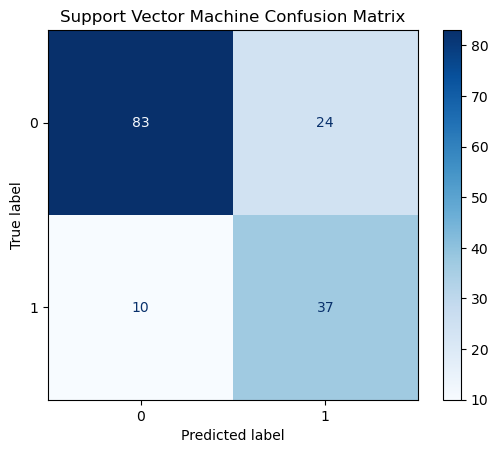

In [41]:
# Employ a confusion matrix to assess sensitivity and specificity from the predictions made
cm_SVM = confusion_matrix(y_test, ypred_SVM)
print(cm_SVM)
# Plot confusion matrix
disp_SVM = ConfusionMatrixDisplay(confusion_matrix=cm_SVM,display_labels=SVM_classifier.classes_)
disp_SVM.plot(cmap=plt.cm.Blues)
plt.title('Support Vector Machine Confusion Matrix')
plt.savefig('Support Vector Machine Confusion Matrix.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

Out of a total of 107 individuals with an actual outcome of 0, the classifier correctly predicted 83 as 0 but misclassified 24 as 1.

Conversely, out of a total of 47 individuals with an actual outcome of 1, the classifier correctly predicted 37 as 1 and misclassified 10 as 0.0.

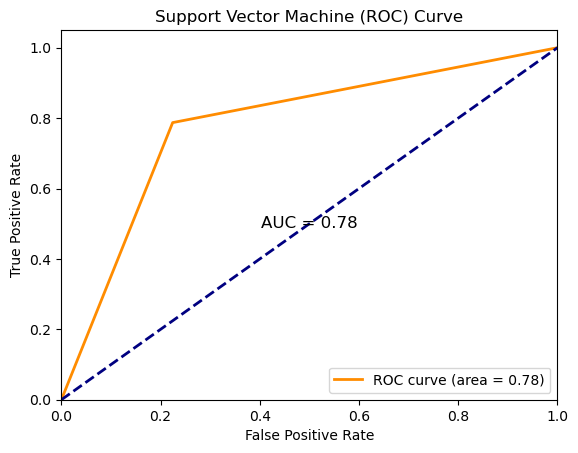

In [42]:
# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, ypred_SVM)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Support Vector Machine (ROC) Curve')
plt.legend(loc="lower right")
plt.text(0.5, 0.5, 'AUC = %0.2f' % roc_auc, ha='center', va='center', fontsize=12)
plt.savefig('SVM (ROC) Curve.png')
plt.show()

In [43]:
# Print the classification report to evaluate the performance of the SVM classifier
print(classification_report(y_test,ypred_SVM))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       107
           1       0.61      0.79      0.69        47

    accuracy                           0.78       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.81      0.78      0.79       154



### 4.Random Forest

In [44]:
# Import & create an instance of the RandomForestClassifier with specified parameters
# Fit the Classifier on the training data
from sklearn.ensemble import RandomForestClassifier
RF_classifier = RandomForestClassifier(n_estimators= 100,criterion='gini',random_state=0)
RF_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [45]:
# Predict the target values for the test set 
ypred_RF = RF_classifier.predict(X_test)
ypred_RF

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [46]:
# Calculating the accuracy score of predictions on the test set
RF_accuracy =accuracy_score(y_test, ypred_RF)
print("Random Forest Accuracy is", RF_accuracy)

Random Forest Accuracy is 0.8051948051948052


[[93 14]
 [16 31]]


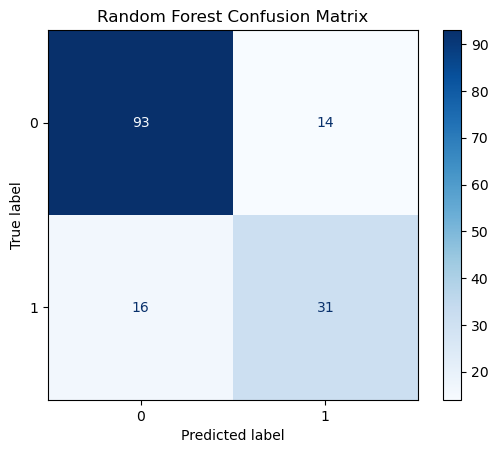

In [47]:
# Employ a confusion matrix to assess sensitivity and specificity from the predictions made
cm_RF = confusion_matrix(y_test, ypred_RF)
print(cm_RF)
# Plot confusion matrix
disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF,display_labels=RF_classifier.classes_)
disp_RF.plot(cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix')
plt.savefig('Random Forest Confusion Matrix.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

Out of a total of 107 individuals with an actual outcome of 0, the classifier correctly predicted 93 as 0 but misclassified 14 as 1.
Althoughl, out of a total of 47 individuals with an actual outcome of 1, the classifier correctly predicted 31 as 1 and misclassified 16 as 0.

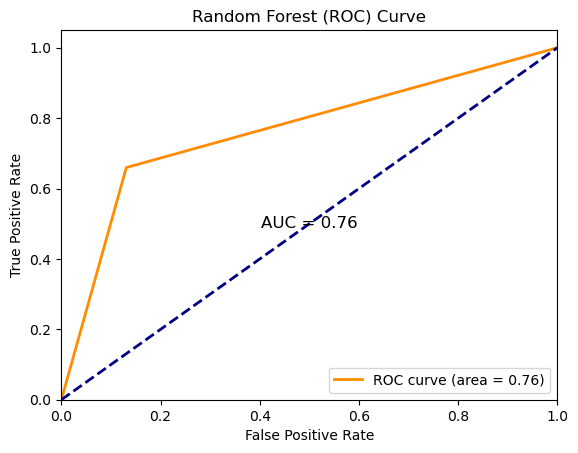

In [48]:
# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, ypred_RF)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest (ROC) Curve')
plt.legend(loc="lower right")
plt.text(0.5, 0.5, 'AUC = %0.2f' % roc_auc, ha='center', va='center', fontsize=12)
plt.savefig('RF (ROC) Curve.png')
plt.show()

In [49]:
# Print the classification report to evaluate the performance of the RF_classifier
print(classification_report(y_test, ypred_RF))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154



### 5.K-Neighrest Neighbors(KNN)

In [50]:
# Import & create an instance of the KNeighborsClassifier with specified parameters
# Fit the Classifier on the training data
from sklearn.neighbors import KNeighborsClassifier
KNN_classifier = KNeighborsClassifier(n_neighbors =9,weights='uniform',metric='minkowski',p=2)
KNN_classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [51]:
# Predict the target values for the test set 
ypred_KNN = KNN_classifier.predict(X_test)
ypred_KNN

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [52]:
#Checking for KNN's accuracy
KNN_accuracy =accuracy_score(y_test, ypred_KNN)        
print("KNN's accuracy is", KNN_accuracy)

KNN's accuracy is 0.7987012987012987


[[93 14]
 [17 30]]


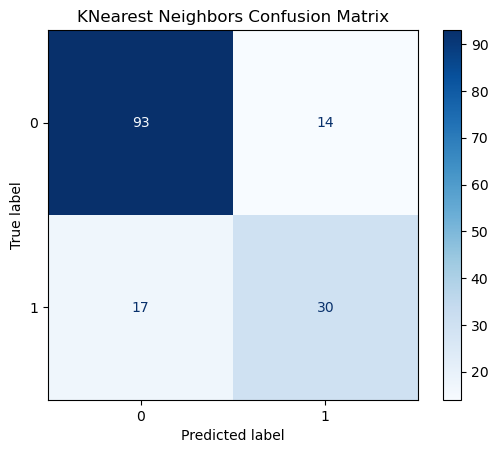

In [53]:
# Employ a confusion matrix to assess sensitivity and specificity from the predictions made
cm_KNN = confusion_matrix(y_test, ypred_KNN)
print(cm_KNN)
# Plot confusion matrix
disp_KNN = ConfusionMatrixDisplay(confusion_matrix=cm_KNN,display_labels=KNN_classifier.classes_)
disp_KNN.plot(cmap=plt.cm.Blues)
plt.title('KNearest Neighbors Confusion Matrix')
plt.savefig('KNearest Neighbors Confusion Matrix.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

For KNN, out of a total of 107 individuals with an actual outcome of 0, the classifier correctly predicted 93 as 0 but misclassified 14 as 1.

On the other hand, out of a total of 47 individuals with an actual outcome of 1, the classifier correctly predicted 30 as 1 but misclassified 17 as 0.

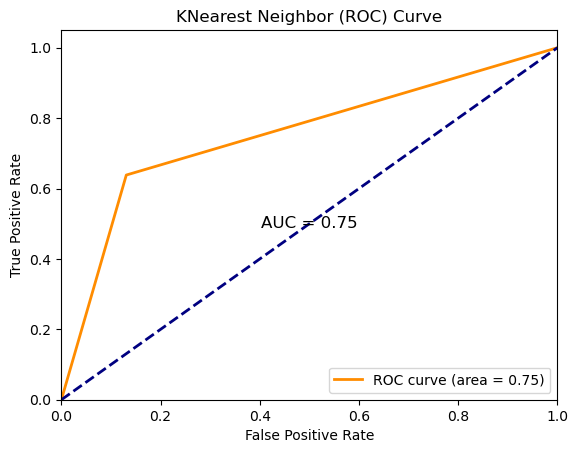

In [54]:
# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, ypred_KNN)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNearest Neighbor (ROC) Curve')
plt.legend(loc="lower right")
plt.text(0.5, 0.5, 'AUC = %0.2f' % roc_auc, ha='center', va='center', fontsize=12)
plt.savefig('KNN (ROC) Curve.png')
plt.show()

In [55]:
# Print the classification report to evaluate the performance of the KNN_classifier
print(classification_report(y_test, ypred_KNN))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.68      0.64      0.66        47

    accuracy                           0.80       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.80      0.80      0.80       154



# Results

                      Model     Score
0                  Logistic  0.811688
4    RandomForestClassifier  0.805195
1                       KNN  0.798701
2                       SVC  0.779221
3  Decision Tree Classifier  0.766234


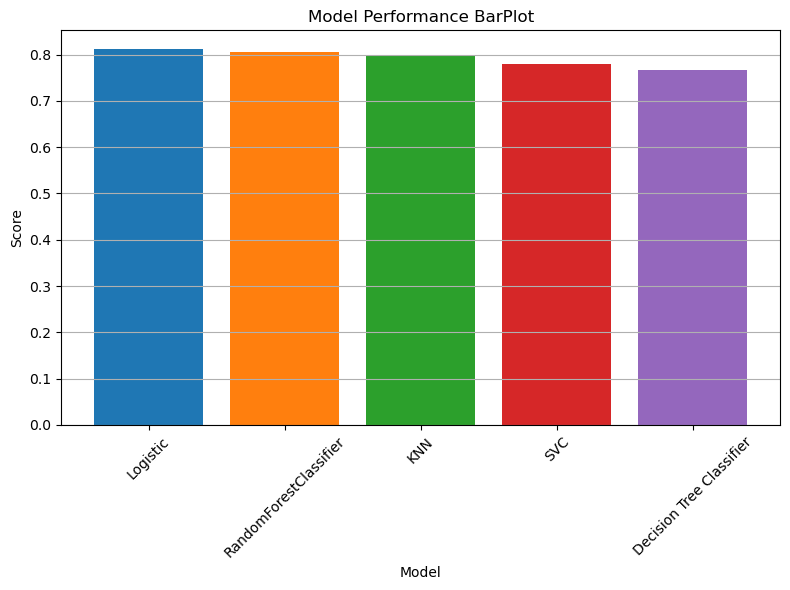

In [56]:
# Creating a DataFrame to compare the performance of different models
models = pd.DataFrame({
    'Model': ['Logistic', 'KNN', 'SVC', 'Decision Tree Classifier', 'RandomForestClassifier'],
    'Score': [LR_accuracy, KNN_accuracy, SVM_accuracy, DT_accuracy, RF_accuracy]
})

# Sorting the DataFrame by the 'Score' column in descending order
models_sorted = models.sort_values(by='Score', ascending=False)
print(models_sorted)

# Plotting the performance of different models
plt.figure(figsize=(8, 6))
plt.bar(models_sorted['Model'], models_sorted['Score'], color=plt.cm.tab10(range(len(models_sorted))))
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance BarPlot')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('model_performance_barplot.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

The above scores offer insight into the performance of each model when tested on the dataset. Notably, the Logistics Regression classifier outperformed the others, boasting the highest accuracy score of 0.8117, showcasing its better performance compared to the rest of the models.

## Best Model Analysis

In logistic regression, we assess the significance of each feature in making predictions by examining the coefficients associated with each feature. Unlike tree-based models, logistic regression models do not have a feature_importances_ attribute. Therefore, we access the coefficients using the coef_ attribute of the trained logistic regression classifier (LR_classifier). These coefficients provide insights into the magnitude and direction of the influence of each feature on the model's predictions.

Proceed to create a plot that visualizes the influence of Logistics Regression coefficients






In [57]:
# Access the coefficients of a Logistic Regression model
LR_classifier.coef_

array([[ 0.32947365,  1.10812685, -0.16165075, -0.0329584 , -0.10149626,
         0.66223673,  0.26309165,  0.21740533]])

Positive coefficients suggest a positive relationship between the feature and the target variable while Negative coefficients suggest a negative relationship between the feature and the target variable.

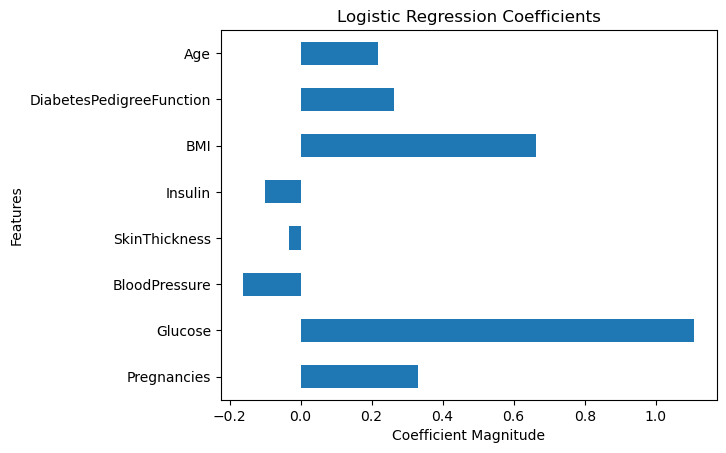

In [58]:
# Create a DataFrame with feature names
X_df = pd.DataFrame(X, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])

# Get coefficients from LR_classifier
coefficients = LR_classifier.coef_[0]

# Create a Series with feature coefficients and their corresponding names
feature_coefficients = pd.Series(coefficients, index=X_df.columns)

# Plot feature coefficients
feature_coefficients.plot(kind='barh')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Features')
plt.title('Logistic Regression Coefficients')
plt.savefig('logistic_regression_coefficients.png')
plt.show()

The negative coefficients result in bars facing left in the horizontal bar plot because they represent features with a negative impact on the predicted outcome.An increase in these features is associated with a decrease in the likelihood of a positive outcome.

In [59]:
# Print prediction probabilities for the test data
LR_classifier.predict_proba(X_test)

array([[0.03687993, 0.96312007],
       [0.81970693, 0.18029307],
       [0.90419684, 0.09580316],
       [0.31256299, 0.68743701],
       [0.89179944, 0.10820056],
       [0.96104542, 0.03895458],
       [0.20624326, 0.79375674],
       [0.11842954, 0.88157046],
       [0.60007216, 0.39992784],
       [0.57574502, 0.42425498],
       [0.39546151, 0.60453849],
       [0.02467206, 0.97532794],
       [0.72023802, 0.27976198],
       [0.824004  , 0.175996  ],
       [0.88089101, 0.11910899],
       [0.85979859, 0.14020141],
       [0.11234383, 0.88765617],
       [0.97799091, 0.02200909],
       [0.59710132, 0.40289868],
       [0.71519226, 0.28480774],
       [0.31965508, 0.68034492],
       [0.5262715 , 0.4737285 ],
       [0.91705493, 0.08294507],
       [0.94214093, 0.05785907],
       [0.94835618, 0.05164382],
       [0.65419884, 0.34580116],
       [0.96430703, 0.03569297],
       [0.06088142, 0.93911858],
       [0.90320043, 0.09679957],
       [0.86041135, 0.13958865],
       [0.

**predict_proba** returns estimates for all classes ordered by the label of classes.The 1st column is the probability of class 0 & 2nd column is that of class 1